In [136]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import os
# print(os.listdir("../input"))

# Load the data
data_df = pd.read_csv("framingham.csv")
print(data_df.columns)
data_df = data_df.drop(columns=["education"])
print(data_df.shape)

print(len(data_df))
# print(data_df[data_df["glucose"].isnull()]["male"].value_counts(normalize=True))
# print(((data_df["glucose"].isnull())  & (data_df["TenYearCHD"] == 0)).sum())
# print(((data_df["totChol"].isnull()) & (data_df["male"] == 0)  & (data_df["TenYearCHD"] == 1)).sum())

# print(data_df.isnull().sum()[data_df.isnull().sum() > 0])
# print(((data_df['TenYearCHD'] == 0) & (data_df["male"] == 0)).sum())


df_nonull = data_df.dropna()
print("No null dataframe", len(df_nonull))


Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')
(4238, 15)
4238
No null dataframe 3749


Test Train split : Need to maintain ratio of TenYearCHD and female male within it!
- Using combined stratification column

| TenYearCHD | 1 (CVD+) | 0 (CVD-) |
|------------|----------|----------|
| **Male (1)**   | 1_1      | 1_0  |
| **Female (0)** | 0_1      | 0_0  | 

Analysing data using histograms!


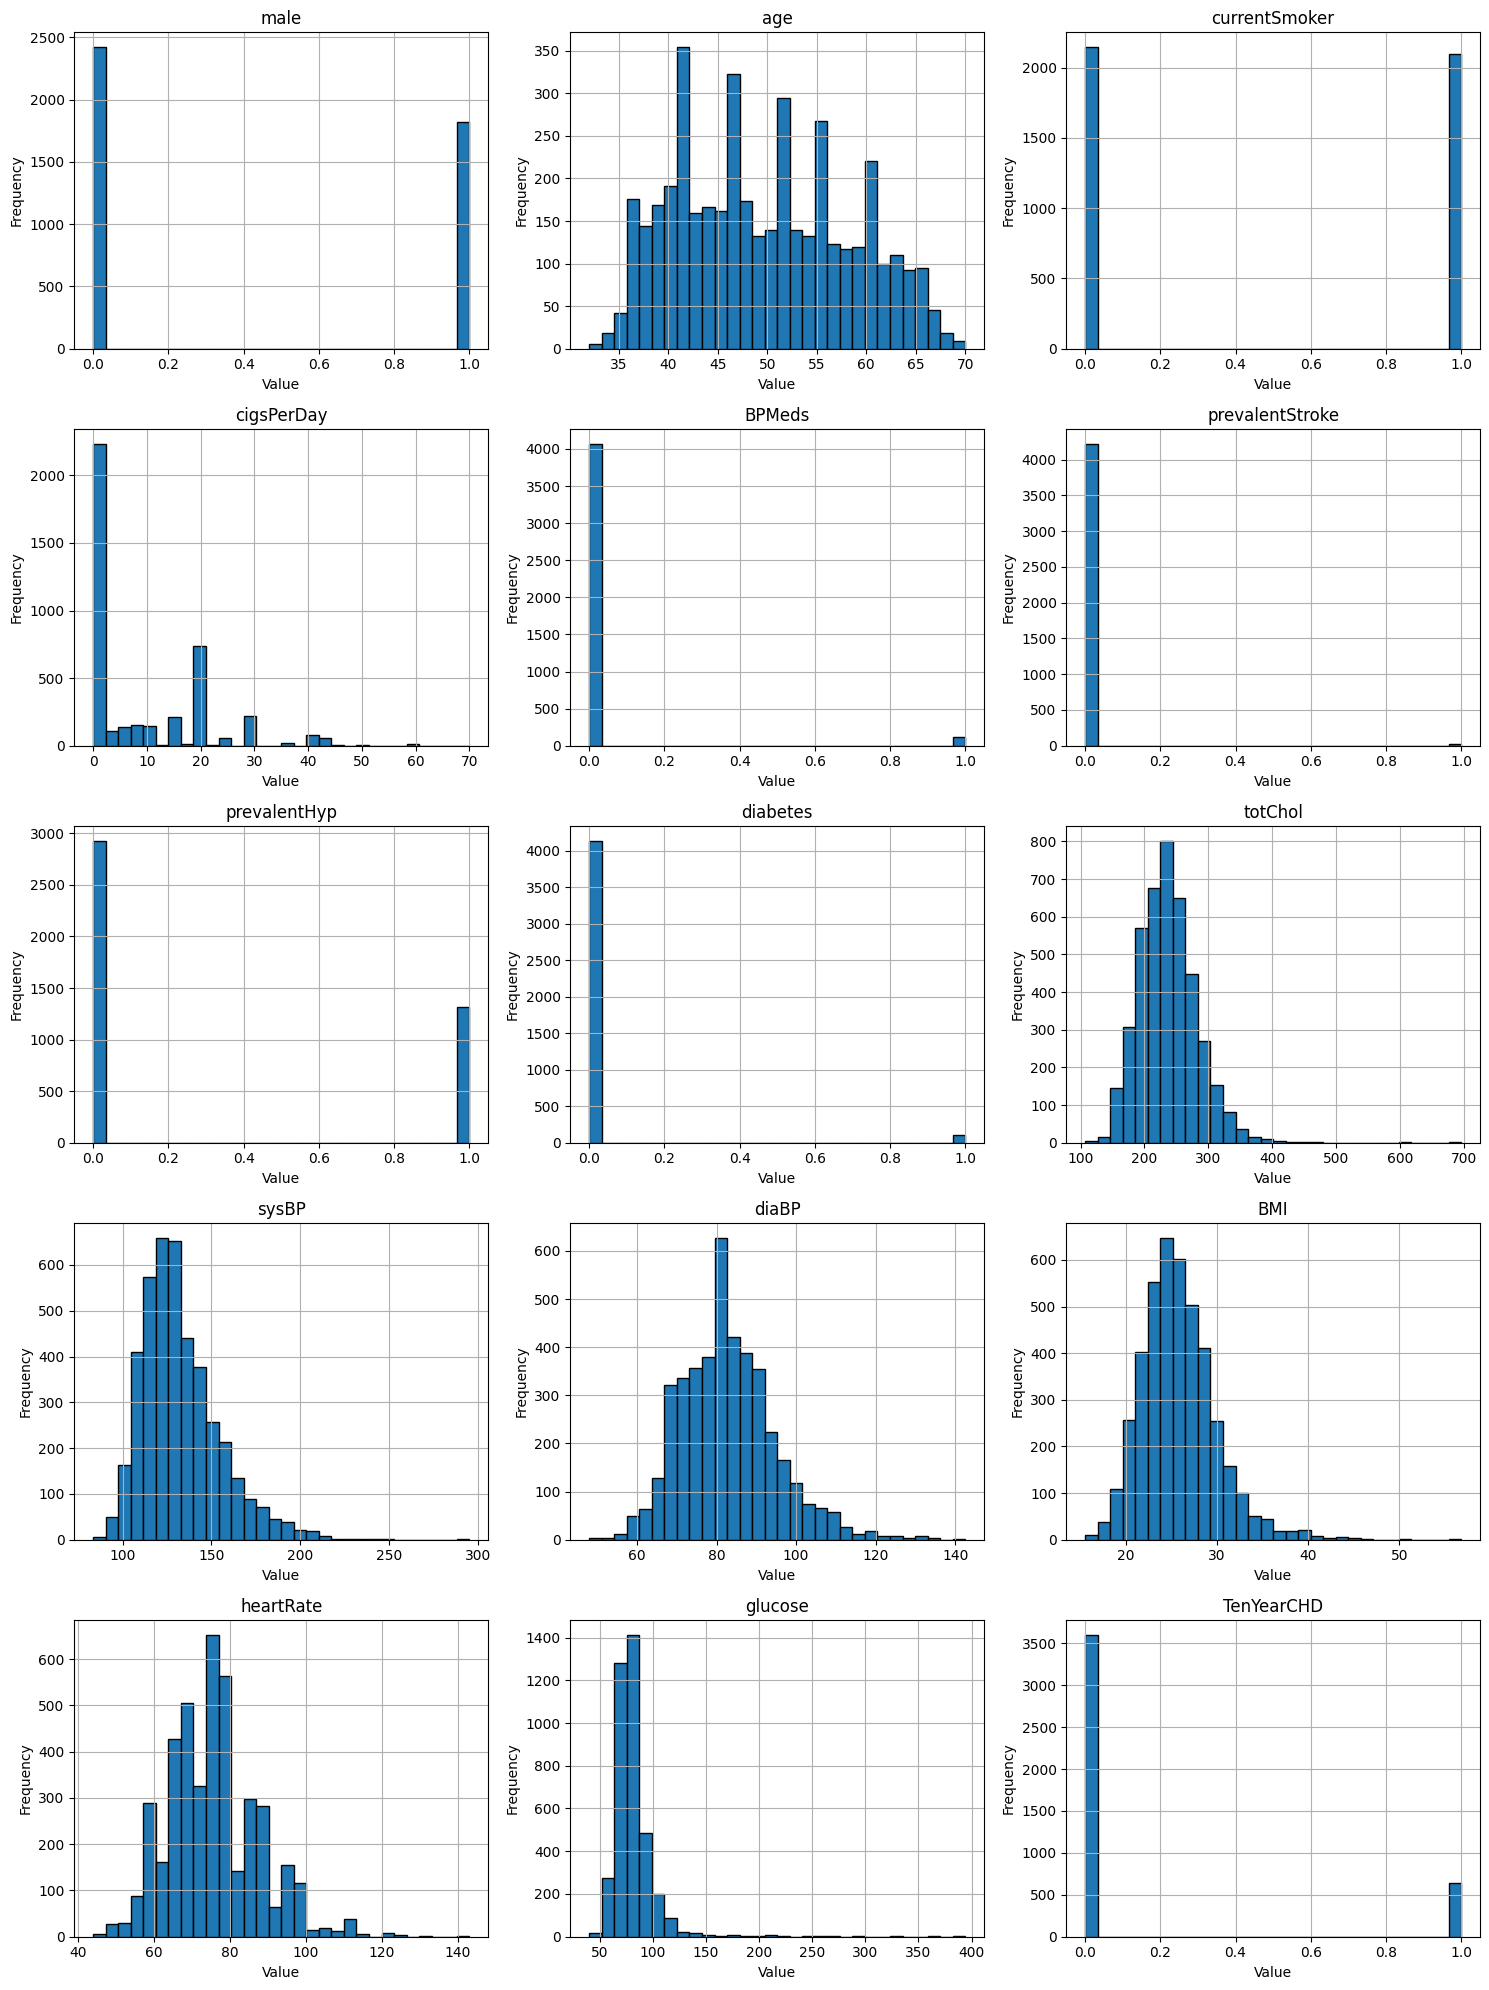

In [137]:
numeric_cols = data_df.select_dtypes(include=["float64", "int64"]).columns

# Create histograms
fig, axes = plt.subplots(nrows = 5, ncols = 3, figsize=(15, 20))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    data_df[col].hist(bins=30, ax=axes[idx], edgecolor='black')
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### Outliers
- Glucose : there seems to be some super high (240mg/dL) is considered to need immediate medical attention 


In [138]:
print((data_df[data_df["glucose"] ==0]).head())


Empty DataFrame
Columns: [male, age, currentSmoker, cigsPerDay, BPMeds, prevalentStroke, prevalentHyp, diabetes, totChol, sysBP, diaBP, BMI, heartRate, glucose, TenYearCHD]
Index: []


In [139]:
df_nonull["stratify"] = df_nonull["TenYearCHD"].astype(str) + "_" + df_nonull["male"].astype(str)
# Creates a new column "stratify" that combines the values of "TenYearCHD" and "male"  
# where if TenYearCHD = 0 and male = 1, then stratify = "0_1"
# print(df_nonull["stratify"].value_counts(normalize=True))

# Use stratified sampling to split the data into training and testing sets
train, test = train_test_split(
    df_nonull,
    test_size=0.2,
    stratify=df_nonull["stratify"],
    random_state=42,
)
train_df = train
test_df = test
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

# print(train_df["stratify"].value_counts(normalize=True))
# print(test_df["stratify"].value_counts(normalize=True))

full_prop  = df_nonull["stratify"].value_counts(normalize=True)
train_prop = train_df["stratify"].value_counts(normalize=True)
test_prop  = test_df["stratify"].value_counts(normalize=True)

# Combine into one table
comparison_table = pd.concat(
    [full_prop, train_prop, test_prop],
    axis=1
)
female_neg = df_nonull[df_nonull["stratify"] == "0_0"].shape[0]
print(f"Number of females with no CHD: {female_neg}")
female_pos = df_nonull[df_nonull["stratify"] == "1_0"].shape[0]
print(f"Number of females with CHD: {female_pos}")
print(f"Ratio of pos to neg female_neg/female_pos: {female_neg/female_pos}")

male_neg = df_nonull[df_nonull["stratify"] == "0_1"].shape[0]
print(f"Number of males with no CHD: {male_neg}")
male_pos = df_nonull[df_nonull["stratify"] == "1_1"].shape[0]
print(f"Number of males with CHD: {male_pos}")
print(f"Ratio of neg to pos male_neg/male_pos: {male_neg/male_pos}")

comparison_table.columns = ["Full Dataset", "Train Set", "Test Set"]

comparison_table = comparison_table.sort_index()

print(comparison_table)

Number of females with no CHD: 1827
Number of females with CHD: 253
Ratio of pos to neg female_neg/female_pos: 7.221343873517786
Number of males with no CHD: 1350
Number of males with CHD: 319
Ratio of neg to pos male_neg/male_pos: 4.231974921630094
          Full Dataset  Train Set  Test Set
stratify                                   
0_0           0.487330   0.487496  0.486667
0_1           0.360096   0.360120  0.360000
1_0           0.067485   0.067356  0.068000
1_1           0.085089   0.085028  0.085333


As evident : spliting by combined column has almost perfectly preserved the ratios.
Full dataset ~ test ~ train

## Imbalance is evident
- For female (male = 0) : For every 7 negatives, there is 1 positive (really bad!)
- For male: For every 4 negatives, 1 positive 
- Oversampling via SMOTE might mess up SHAP interpretations since datapoints won't be "real"
- Class weights might work better


### Class weights

In [140]:
trainNoChdCount = train_df[train_df["TenYearCHD"] == 0].shape[0]
trainChdCount = train_df[train_df["TenYearCHD"] == 1].shape[0]

scale_pos_weight = trainNoChdCount / trainChdCount

### training model

In [141]:
X_train = train_df.drop(columns=["TenYearCHD", "stratify"])
y_train = train_df["TenYearCHD"]

X_test = test_df.drop(columns=["TenYearCHD", "stratify"])
y_test = test_df["TenYearCHD"]

from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
)
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [142]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print(f"AUROC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(roc_auc_score(y_test, y_pred_proba))

import pickle

with open("xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)
    

              precision    recall  f1-score   support

           0       0.89      0.74      0.81       635
           1       0.26      0.52      0.35       115

    accuracy                           0.70       750
   macro avg       0.58      0.63      0.58       750
weighted avg       0.80      0.70      0.74       750

AUROC: 0.708
0.70841492639507


## Grid search approach omg

In [143]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'max_depth': [3, 4, 5, 6],
#     'n_estimators': [150, 200, 250],
#     'learning_rate': [0.03, 0.05, 0.07],
#     'min_child_weight': [1, 3, 5],
#     'gamma': [0, 0.1, 0.2],
#     'subsample': [0.8, 0.9, 1.0]
# }

# grid = GridSearchCV(
#     XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42),
#     param_grid,
#     cv=5,
#     scoring='roc_auc',
#     n_jobs=-1,
#     verbose=2
# )

# grid.fit(X_train, y_train)
# model2 = grid.best_estimator_

# with open("gridxgb_model.pkl", "wb") as f:
#     pickle.dump(model2, f)

Random forest

In [144]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',  # Handles imbalance
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)